# L=32 XY — apples-to-apples raw PCA versus cos/sin-channel ResNet

Both methods begin with the identical physical variables $(\cos\theta_i,\sin\theta_i)$ for every site and use the same observations. Raw PCA receives the flattened values directly. ResNet receives them as two spatial image channels, with an information-free third channel, before fixed ImageNet normalization and frozen nonlinear feature extraction.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

OUT=Path('/home/lledson/senior-thesis/data/processed/xy32_broad/matched_all_bins')
N_RUNS,N_T,BINS=10_000,41,10
N_CONFIGS=N_RUNS*N_T*BINS
RATIOS=np.array([.60,.70,.78,.84,.87,.89,.90,.91,.92,.93,.94,.95,.96,.97,.98,.99,1.00,1.01,1.02,1.03,1.04,1.05,1.06,1.07,1.08,1.09,1.10,1.11,1.12,1.13,1.14,1.15,1.16,1.17,1.18,1.19,1.20,1.30,1.45,1.60,1.80])
temperature_ids=np.tile(np.repeat(np.arange(N_T,dtype=np.int8),BINS),N_RUNS)
fit_bins=(np.arange(N_RUNS)[:,None]+np.arange(N_T)[None,:])%BINS
FIT_INDICES=((np.arange(N_RUNS)[:,None]*N_T+np.arange(N_T)[None,:])*BINS+fit_bins).reshape(-1)
rng=np.random.default_rng(42)
EVAL_INDICES=[]
for ti in range(N_T):
    candidates=((np.arange(N_RUNS)*N_T+ti)*BINS)[:,None]+np.arange(BINS)
    EVAL_INDICES.append(rng.choice(candidates.ravel(),125,replace=False))
EVAL_INDICES=np.concatenate(EVAL_INDICES)

raw_scores=np.load(OUT/'raw_spin_pc1-40_scores.npy',mmap_mode='r')
res_scores=np.load(OUT/'resnet18_cossin_pc1-40_scores.npy',mmap_mode='r')

def features(block,kind):
    block=np.asarray(block,dtype=np.float32)
    if kind=='ring_aware':
        radius=np.sqrt(block[:,0]**2+block[:,1]**2)[:,None]
        return np.concatenate([radius,block[:,2:40]],axis=1)
    return block[:,:40]

def exact_cluster(scores,kind,prefix):
    model=KMeans(2,random_state=42,n_init=10,max_iter=300,algorithm='lloyd').fit(features(scores[FIT_INDICES,:40],kind))
    path=OUT/f'{prefix}_matched_exact_cluster_labels.npy'
    labels=np.lib.format.open_memmap(path,mode='w+',dtype=np.int8,shape=(N_CONFIGS,))
    for start in range(0,N_CONFIGS,100_000):
        stop=min(start+100_000,N_CONFIGS)
        labels[start:stop]=model.predict(features(scores[start:stop,:40],kind))
    labels.flush(); unordered=np.asarray(labels)
    means=[RATIOS[temperature_ids[unordered==k]].mean() for k in range(2)]
    order=np.argsort(means); mapping=np.empty(2,dtype=np.int8); mapping[order[0]]=0; mapping[order[1]]=1
    labels[:]=mapping[unordered]; labels.flush(); aligned=np.asarray(labels)
    pop=np.stack([(aligned.reshape(N_RUNS,N_T,BINS)==k).mean((0,2)) for k in range(2)])
    sil=float(silhouette_score(features(scores[EVAL_INDICES,:40],kind),aligned[EVAL_INDICES]))
    return labels,pop,{'silhouette':sil,'inertia':float(model.inertia_),'iterations':int(model.n_iter_),'low_endpoint_high_cluster_fraction':float(pop[1,0]),'at_TBKT_high_cluster_fraction':float(pop[1,16]),'high_endpoint_high_cluster_fraction':float(pop[1,-1])}

raw_labels,raw_pop,raw_diag=exact_cluster(raw_scores,'ring_aware','raw_spin')
res_labels,res_pop,res_diag=exact_cluster(res_scores,'ring_aware','resnet18_cossin')
ami=float(adjusted_mutual_info_score(raw_labels,res_labels))
raw_summary=json.loads((OUT/'raw_spin_summary.json').read_text())
res_summary=json.loads((OUT/'resnet18_cossin_summary.json').read_text())
comparison=pd.DataFrame({
    'representation':['Raw cos/sin PCA','Frozen ResNet-18: cos/sin channels'],
    'input variables':['flattened cos(theta), sin(theta)','spatial R=cos(theta), G=sin(theta), neutral B'],
    'PCs for 90% variance':[raw_summary['n90'],res_summary['n90']],
    'clustering features':['PC1-PC2 radius + PCs 3-40','PC1-PC2 radius + PCs 3-40'],
    'exact K-means silhouette':[raw_diag['silhouette'],res_diag['silhouette']],
    'low-T high-cluster fraction':[raw_diag['low_endpoint_high_cluster_fraction'],res_diag['low_endpoint_high_cluster_fraction']],
    'at TBKT high-cluster fraction':[raw_diag['at_TBKT_high_cluster_fraction'],res_diag['at_TBKT_high_cluster_fraction']],
    'high-T high-cluster fraction':[raw_diag['high_endpoint_high_cluster_fraction'],res_diag['high_endpoint_high_cluster_fraction']],
})
comparison['cross-representation AMI']=ami
comparison.to_csv(OUT/'xy32_cossin_apples_to_apples_comparison.csv',index=False)
(OUT/'xy32_cossin_apples_to_apples_diagnostics.json').write_text(json.dumps({'raw':raw_diag,'resnet_cossin':res_diag,'AMI':ami},indent=2))
comparison


,representation,input variables,PCs for 90% variance,clustering features,exact K-means silhouette,low-T high-cluster fraction,at TBKT high-cluster fraction,high-T high-cluster fraction,cross-representation AMI
0,Raw cos/sin PCA,"flattened cos(theta), sin(theta)",1158,PC1-PC2 radius + PCs 3-40,0.236187,0.00000,0.00101,1.00000,0.218217
1,Frozen ResNet-18: cos/sin channels,"spatial R=cos(theta), G=sin(theta), neutral B",43,PC1-PC2 radius + PCs 3-40,0.142939,0.05052,0.37584,0.99968,0.218217


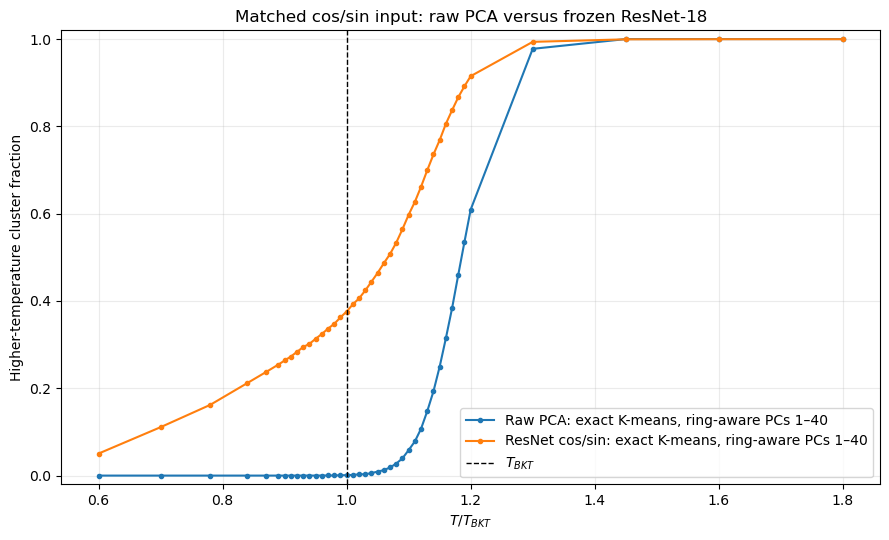

In [2]:
fig,ax=plt.subplots(figsize=(9,5.5))
ax.plot(RATIOS,raw_pop[1],'o-',ms=3,label='Raw PCA: exact K-means, ring-aware PCs 1–40')
ax.plot(RATIOS,res_pop[1],'o-',ms=3,label='ResNet cos/sin: exact K-means, ring-aware PCs 1–40')
ax.axvline(1,color='black',ls='--',lw=1,label=r'$T_{BKT}$')
ax.set(xlabel=r'$T/T_{BKT}$',ylabel='Higher-temperature cluster fraction',title='Matched cos/sin input: raw PCA versus frozen ResNet-18',ylim=(-.02,1.02))
ax.grid(alpha=.25); ax.legend(); fig.tight_layout()
fig.savefig(OUT/'xy32_cossin_apples_to_apples_cluster_comparison.png',dpi=220)
plt.show(); plt.close(fig)


## Interpretation

The two rows share the underlying spin variables, all observation indices, PCA-fit balance, exact K-means implementation, first-40-PC information, PC1–PC2 radial transformation, and silhouette evaluation sample. The remaining intentional difference is the representation under study: raw linear PCA versus pretrained ResNet's spatial and nonlinear transformation. The ResNet analysis notebook also reports direct 40-PC K-means; its nearly temperature-independent low-temperature population exposes global-orientation/color sensitivity, so the radial comparison here is the appropriate symmetry-matched result.